# BNN Classification on Two Moons using ```laplace-torch```

In this project, we utilize the classic Two Moons dataset to demonstrate uncertainty quantification using Laplace Approximation through the ```laplace-torch``` library. 



In [ ]:
from pathlib import Path
import sys
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from laplace import Laplace

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import TinyMLP, compute_metrics, eval_probs, load_two_moons, train_map

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

COLOR_MAP = '#4682B4'    
COLOR_DIAG = '#4682B4'   
COLOR_FULL = '#FF6347'  
COLOR_KRON = '#228B22'   
COLOR_GRID = '#9370DB'   
COLOR_MARGLIK = '#228B22'  

metrics_dict = {
    'MAP Baseline': {},
}


Device: cuda


Train: 6000  Val: 2000  Test: 2000


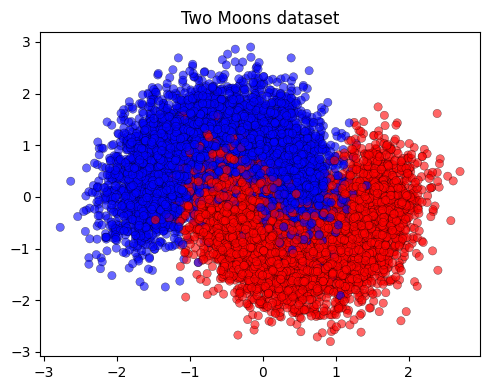

Saved: figures/01_raw_dataset.png


In [ ]:
data = load_two_moons(seed=42, device=device)

X = data['X']
y = data['y']
X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']
train_ds = data['train_ds']
val_ds = data['val_ds']
test_ds = data['test_ds']
train_loader = data['train_loader']
val_loader = data['val_loader']
test_loader = data['test_loader']

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6, edgecolors='k', linewidths=0.3)
ax.set_title('Two Moons dataset')
plt.tight_layout()
plt.savefig('figures/01_raw_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/01_raw_dataset.png')

In [ ]:
model = TinyMLP(hidden=64).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')
print(model)

Parameters: 4,482
TinyMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


MAP training time: 468.1901s
MAP test accuracy: 92.2%


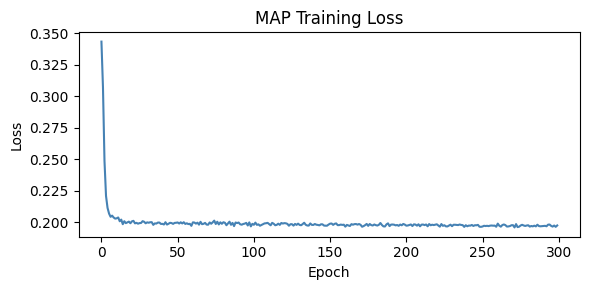

Saved: figures/02_map_training_loss.png


In [ ]:
import os

SEED = 42
checkpoint_dir = os.path.join('results', 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, 'two_moons_map_seed42.pt')

model, train_losses, fit_time = train_map(
    model,
    train_loader,
    epochs=300,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
    seed=SEED,
    checkpoint_path=checkpoint_path,
)
metrics_dict['MAP Baseline']['Fit_Time (s)'] = fit_time
print(f"MAP training time: {fit_time:.4f}s")
model.eval()

inf_start = time.time()
map_probs = eval_probs(model, test_loader, device=device)
metrics_dict['MAP Baseline']['Inf_Time (s)'] = time.time() - inf_start
metrics_dict['MAP Baseline'].update(compute_metrics(map_probs, y_test))
map_metrics = metrics_dict['MAP Baseline']
print(f"MAP test accuracy: {map_metrics['Accuracy']*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(train_losses, color=COLOR_MAP, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('MAP Training Loss')
plt.tight_layout()
plt.savefig('figures/02_map_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/02_map_training_loss.png')

In [5]:
def plot_boundary(predict_fn, X_data, y_data, title, ax=None):
    """predict_fn: takes (N,2) numpy array, returns (N,) prob of class 1"""
    h = 0.05
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_fn(grid).reshape(xx.shape)

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    cf = ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.8, vmin=0, vmax=1)
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap='bwr', edgecolors='k', linewidths=0.4, s=30, zorder=3)
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    return cf, probs


def uncertainty_map(predict_fn, X_data, y_data, title, ax):
    """Visualise epistemic uncertainty as distance from 0.5 probability."""
    h = 0.05
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_fn(grid).reshape(xx.shape)
    uncertainty = 1 - 2 * np.abs(probs - 0.5)  # 1 = max uncertainty, 0 = certain

    cf = ax.contourf(xx, yy, uncertainty, levels=50, cmap='YlOrRd', vmin=0, vmax=1)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap='bwr', edgecolors='k', linewidths=0.4, s=30, zorder=3)
    ax.set_title(title)
    return cf, uncertainty


def make_scatter_comparison(ax, x_label, x_data, y_label, y_data, title, c_data=y_test):
    """Standard scatter plot: x on horizontal, y on vertical, colored by true label."""
    ax.scatter(x_data, y_data, alpha=0.4, s=15, c=c_data, cmap='bwr', edgecolors='k', linewidths=0.2)
    lims = [0, 1.01]
    ax.plot(lims, lims, 'k--', linewidth=1, label='no change')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    return ax


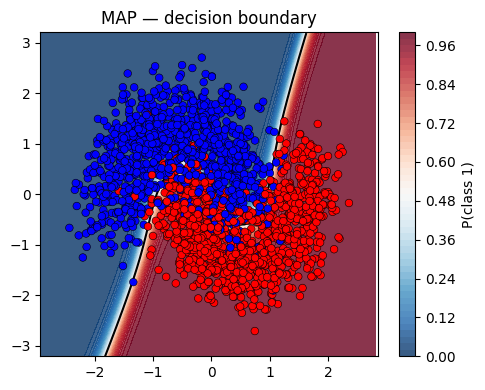

Saved: figures/03_map_boundary.png


In [6]:
def map_predict(X_np):
    x = torch.tensor(X_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)
    return probs[:, 1].cpu().numpy()

# ── Figure: MAP decision boundary ──
fig, ax = plt.subplots(figsize=(5, 4))
cf, _ = plot_boundary(map_predict, X_test, y_test, 'MAP — decision boundary', ax=ax)
plt.colorbar(cf, ax=ax, label='P(class 1)')
plt.tight_layout()
plt.savefig('figures/03_map_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/03_map_boundary.png')

In [7]:
la_diag_grid = Laplace(
    model,
    'classification',
    subset_of_weights='all',
    hessian_structure='diag'
)

fit_start = time.time()
la_diag_grid.fit(train_loader)
metrics_dict["Laplace_Diag_GridSearch_all"] = {}
metrics_dict["Laplace_Diag_GridSearch_all"]["Fit_Time (s)"] = time.time() - fit_start
print('Laplace (diag, gridsearch) fitted.')

tune_start = time.time()
la_diag_grid.optimize_prior_precision(
    method='gridsearch',
    pred_type='glm',
    link_approx='probit',
    val_loader=val_loader
)
metrics_dict["Laplace_Diag_GridSearch_all"]["Tune_Time (s)"] = time.time() - tune_start
print(f'Optimal prior precision (gridsearch): {la_diag_grid.prior_precision.item():.4f}')

correct = total = 0
inf_start = time.time()
lap_la_diag_grid_probs = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        probs = la_diag_grid(xb, pred_type='glm', link_approx='probit')
        preds = probs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += len(yb)
        lap_la_diag_grid_probs.append(probs)
metrics_dict["Laplace_Diag_GridSearch_all"]["Inf_Time (s)"] = time.time() - inf_start
lap_probs_cat = torch.cat(lap_la_diag_grid_probs).cpu().numpy()
map_unc = float((1 - lap_probs_cat.max(axis=1)).mean())
metrics_dict["Laplace_Diag_GridSearch_all"]["Mean_Uncertainty"] = map_unc
metrics_dict["Laplace_Diag_GridSearch_all"]["Prior_Precision"] = la_diag_grid.prior_precision.item()
print(f'Laplace (diag, gridsearch) test accuracy: {100*correct/total:.1f}%')

# Store for later use
la_gs = la_diag_grid  # alias

Laplace (diag, gridsearch) fitted.


/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/laplace/baselaplace.py:435: UserWarning: By default `link_approx` is `probit`. Make sure to set it equals to the way you want to call `la(test_data, pred_type=..., link_approx=...)`.
  warnings.warn(


Optimal prior precision (gridsearch): 10000.0000
Laplace (diag, gridsearch) test accuracy: 92.2%


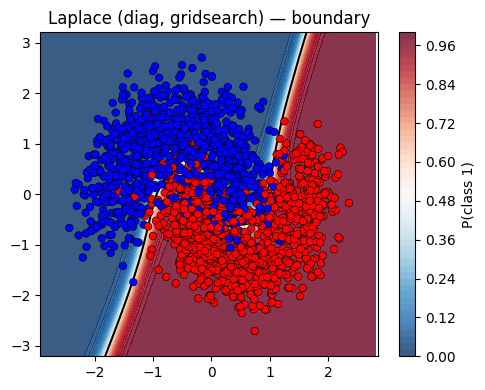

Saved: figures/04_laplace_diag_grid_boundary.png


In [8]:
def la_predict(X_np, la_model, batch_size=256):
    results = []
    x_tensor = torch.tensor(X_np, dtype=torch.float32)
    for i in range(0, len(x_tensor), batch_size):
        batch = x_tensor[i:i+batch_size].to(device)
        with torch.no_grad():
            probs = la_model(batch, pred_type='glm', link_approx='probit')
        results.append(probs[:, 1].cpu())
    return torch.cat(results).numpy()

# ── Figure: Laplace (diag, gridsearch) decision boundary ──
fig, ax = plt.subplots(figsize=(5, 4))
cf, _ = plot_boundary(lambda X: la_predict(X, la_gs), X_test, y_test, 'Laplace (diag, gridsearch) — boundary', ax=ax)
plt.colorbar(cf, ax=ax, label='P(class 1)')
plt.tight_layout()
plt.savefig('figures/04_laplace_diag_grid_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/04_laplace_diag_grid_boundary.png')

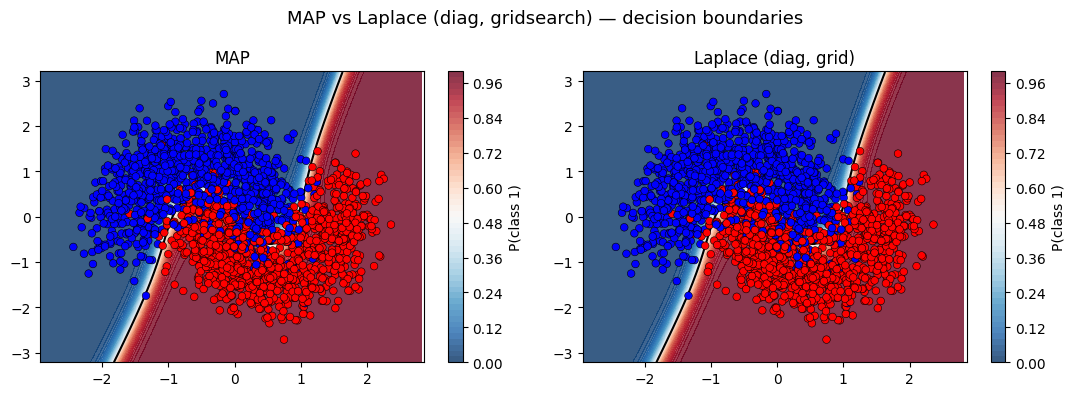

Saved: figures/05_map_vs_laplace_boundary.png


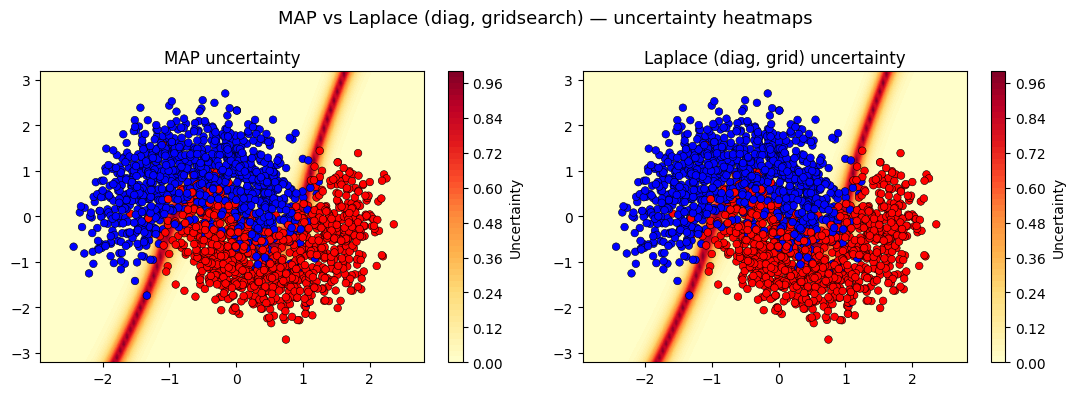

Saved: figures/06_map_vs_laplace_uncertainty.png


In [9]:
# ── Figure: MAP vs Laplace (diag, gridsearch) decision boundaries ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cf1, _ = plot_boundary(map_predict, X_test, y_test, 'MAP', axes[0])
cf2, _ = plot_boundary(lambda X: la_predict(X, la_gs), X_test, y_test, 'Laplace (diag, grid)', axes[1])

plt.colorbar(cf1, ax=axes[0], label='P(class 1)')
plt.colorbar(cf2, ax=axes[1], label='P(class 1)')
plt.suptitle('MAP vs Laplace (diag, gridsearch) — decision boundaries', fontsize=13)
plt.tight_layout()
plt.savefig('figures/05_map_vs_laplace_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/05_map_vs_laplace_boundary.png')

# ── Figure: MAP vs Laplace (diag, gridsearch) uncertainty heatmaps ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cf1, _ = uncertainty_map(map_predict, X_test, y_test, 'MAP uncertainty', axes[0])
cf2, _ = uncertainty_map(lambda X: la_predict(X, la_gs), X_test, y_test, 'Laplace (diag, grid) uncertainty', axes[1])

plt.colorbar(cf1, ax=axes[0], label='Uncertainty')
plt.colorbar(cf2, ax=axes[1], label='Uncertainty')
plt.suptitle('MAP vs Laplace (diag, gridsearch) — uncertainty heatmaps', fontsize=13)
plt.tight_layout()
plt.savefig('figures/06_map_vs_laplace_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/06_map_vs_laplace_uncertainty.png')

In [10]:
la_diag_marglik = Laplace(
    model,
    'classification',
    subset_of_weights='all',
    hessian_structure='diag'
)

fit_start = time.time()
la_diag_marglik.fit(train_loader)
metrics_dict["Laplace_Diag_MargLik_all"] = {}
metrics_dict["Laplace_Diag_MargLik_all"]["Fit_Time (s)"] = time.time() - fit_start
print('Laplace (diag, marglik) fitted.')

tune_start = time.time()
la_diag_marglik.optimize_prior_precision(method='marglik')
metrics_dict["Laplace_Diag_MargLik_all"]["Tune_Time (s)"] = time.time() - tune_start

print(f'Prior precision (marglik): {la_diag_marglik.prior_precision.item():.4f}')
metrics_dict["Laplace_Diag_MargLik_all"]["Prior_Precision"] = la_diag_marglik.prior_precision.item()

correct = total = 0
inf_start = time.time()
lap_la_diag_marglik_probs = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        probs = la_diag_marglik(xb, pred_type='glm', link_approx='probit')
        preds = probs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += len(yb)
        lap_la_diag_marglik_probs.append(probs)
metrics_dict["Laplace_Diag_MargLik_all"]["Inf_Time (s)"] = time.time() - inf_start
lap_probs_cat = torch.cat(lap_la_diag_marglik_probs).cpu().numpy()
map_unc = float((1 - lap_probs_cat.max(axis=1)).mean())
metrics_dict["Laplace_Diag_MargLik_all"]["Mean_Uncertainty"] = map_unc
print(f'Laplace (diag, marglik) test accuracy: {100*correct/total:.1f}%')

# Store for later use
la_ml = la_diag_marglik  # alias

Laplace (diag, marglik) fitted.
Prior precision (marglik): 8.5844
Laplace (diag, marglik) test accuracy: 92.2%


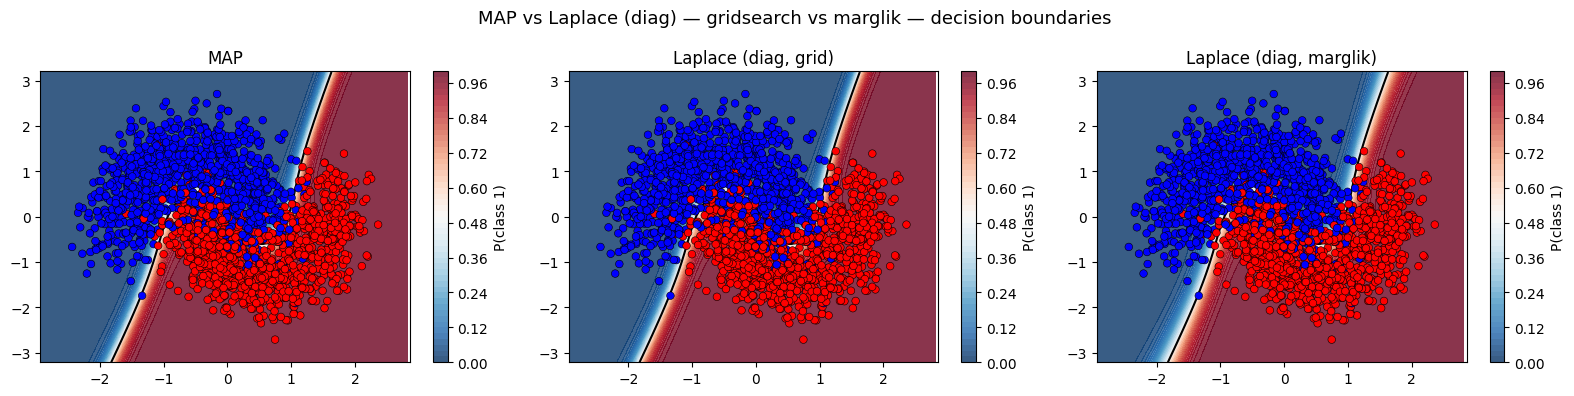

Saved: figures/07_three_way_boundary.png


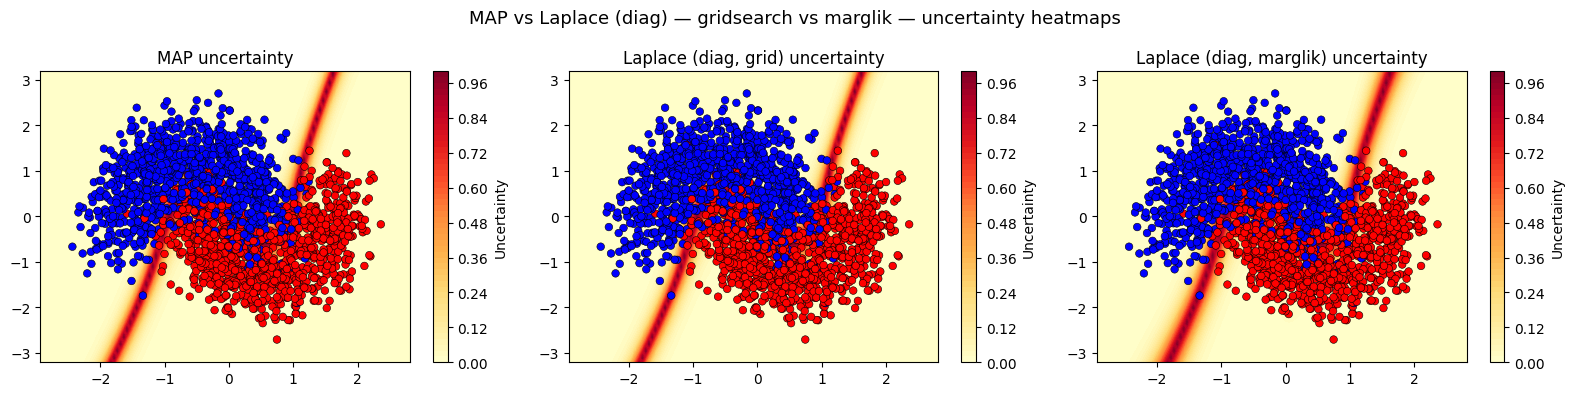

Saved: figures/08_three_way_uncertainty.png


In [11]:
# ── Figure: Three-way decision boundaries ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cf0, _ = plot_boundary(map_predict,        X_test, y_test, 'MAP',                          axes[0])
cf1, _ = plot_boundary(lambda X: la_predict(X, la_gs), X_test, y_test, 'Laplace (diag, grid)',  axes[1])
cf2, _ = plot_boundary(lambda X: la_predict(X, la_ml), X_test, y_test, 'Laplace (diag, marglik)', axes[2])

for cf, ax in zip([cf0, cf1, cf2], axes):
    plt.colorbar(cf, ax=ax, label='P(class 1)')

plt.suptitle('MAP vs Laplace (diag) — gridsearch vs marglik — decision boundaries', fontsize=13)
plt.tight_layout()
plt.savefig('figures/07_three_way_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/07_three_way_boundary.png')

# ── Figure: Three-way uncertainty heatmaps ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cf0, _ = uncertainty_map(map_predict,        X_test, y_test, 'MAP uncertainty',              axes[0])
cf1, _ = uncertainty_map(lambda X: la_predict(X, la_gs), X_test, y_test, 'Laplace (diag, grid) uncertainty',  axes[1])
cf2, _ = uncertainty_map(lambda X: la_predict(X, la_ml), X_test, y_test, 'Laplace (diag, marglik) uncertainty', axes[2])

for cf, ax in zip([cf0, cf1, cf2], axes):
    plt.colorbar(cf, ax=ax, label='Uncertainty')

plt.suptitle('MAP vs Laplace (diag) — gridsearch vs marglik — uncertainty heatmaps', fontsize=13)
plt.tight_layout()
plt.savefig('figures/08_three_way_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/08_three_way_uncertainty.png')

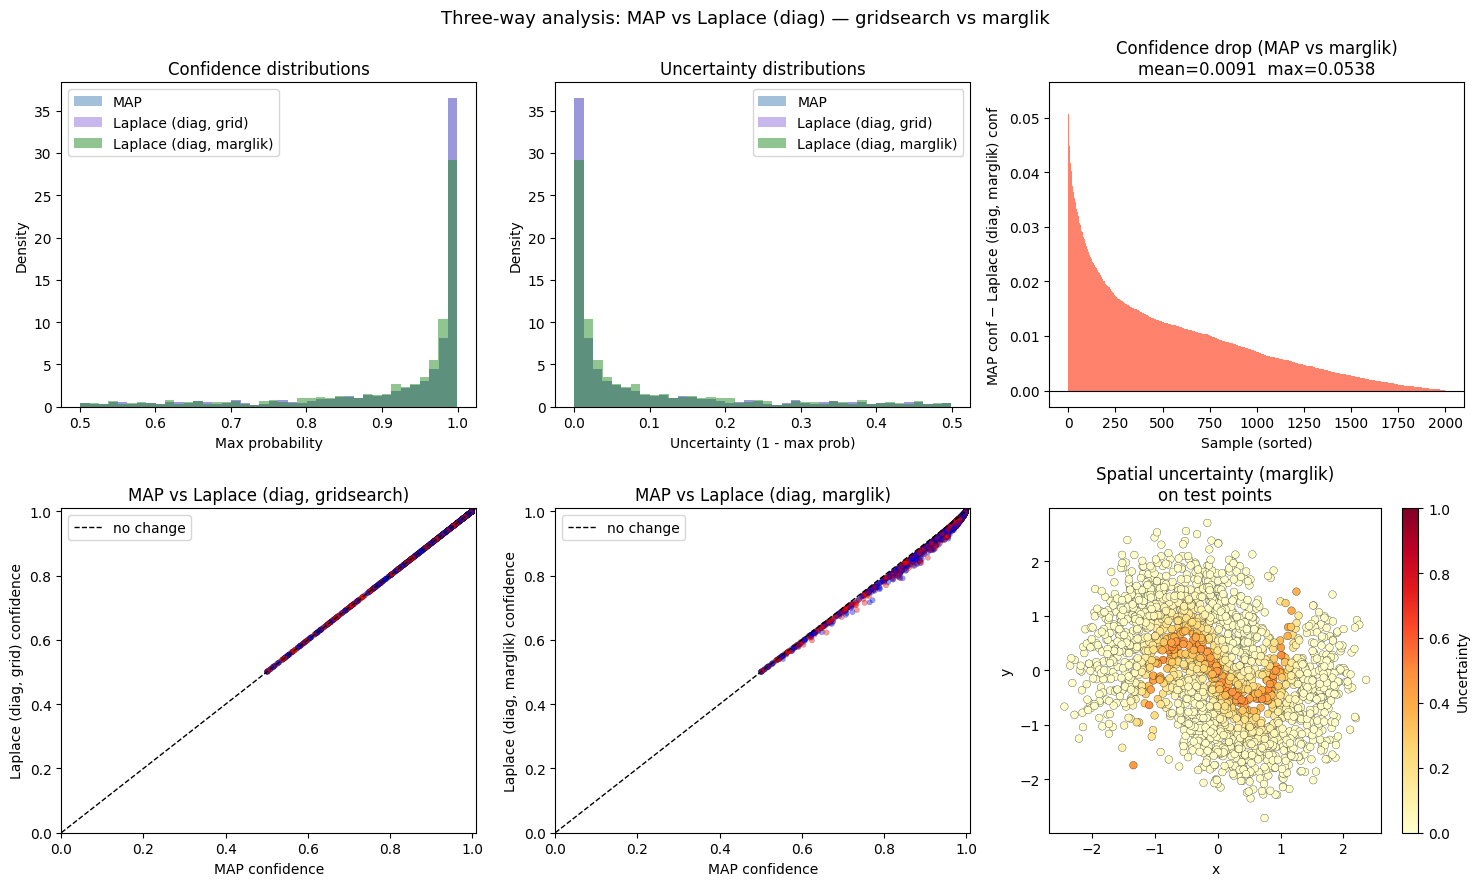

Saved: figures/09_three_way_analysis.png
Prior precision — gridsearch: 10000.0000
Prior precision — marglik:    8.5844
MAP accuracy:          92.2%
Laplace (diag, grid) accuracy: 92.2%
Laplace (diag, marglik) acc:   92.2%


In [12]:
# ── Compute per-sample predictions ──
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    map_probs_test = F.softmax(model(X_test_t), dim=1).cpu().numpy()

la_gs_list = []
la_ml_list = []
for i in range(0, len(X_test_t), 64):
    batch = X_test_t[i:i+64]
    with torch.no_grad():
        la_gs_list.append(la_gs(batch, pred_type='glm', link_approx='probit').cpu())
        la_ml_list.append(la_ml(batch, pred_type='glm', link_approx='probit').cpu())
la_gs_probs = torch.cat(la_gs_list).numpy()
la_ml_probs = torch.cat(la_ml_list).numpy()

map_conf = map_probs_test.max(axis=1)
gs_conf  = la_gs_probs.max(axis=1)
ml_conf  = la_ml_probs.max(axis=1)

map_unc  = 1 - map_conf
gs_unc   = 1 - gs_conf
ml_unc   = 1 - ml_conf

map_preds = map_probs_test.argmax(axis=1)
gs_preds  = la_gs_probs.argmax(axis=1)
ml_preds  = la_ml_probs.argmax(axis=1)

# ── Figure: Three-way per-sample analysis ──
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Confidence distributions
axes[0,0].hist(map_conf, bins=40, alpha=0.5, label='MAP',              color=COLOR_MAP, density=True)
axes[0,0].hist(gs_conf,  bins=40, alpha=0.5, label='Laplace (diag, grid)', color=COLOR_GRID, density=True)
axes[0,0].hist(ml_conf,  bins=40, alpha=0.5, label='Laplace (diag, marglik)', color=COLOR_MARGLIK, density=True)
axes[0,0].set_xlabel('Max probability')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Confidence distributions')
axes[0,0].legend()

# 2. Uncertainty distributions
axes[0,1].hist(map_unc, bins=40, alpha=0.5, label='MAP',              color=COLOR_MAP, density=True)
axes[0,1].hist(gs_unc,  bins=40, alpha=0.5, label='Laplace (diag, grid)', color=COLOR_GRID, density=True)
axes[0,1].hist(ml_unc,  bins=40, alpha=0.5, label='Laplace (diag, marglik)', color=COLOR_MARGLIK, density=True)
axes[0,1].set_xlabel('Uncertainty (1 - max prob)')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Uncertainty distributions')
axes[0,1].legend()

# 3. Per-sample confidence drop: MAP vs marglik
diff_ml = map_conf - ml_conf
sorted_diff = np.sort(diff_ml)[::-1]
axes[0,2].bar(range(len(sorted_diff)), sorted_diff,
              color=np.where(sorted_diff > 0, COLOR_FULL, COLOR_MAP),
              width=1.0, alpha=0.8)
axes[0,2].axhline(0, color='k', linewidth=0.8)
axes[0,2].set_xlabel('Sample (sorted)')
axes[0,2].set_ylabel('MAP conf $-$ Laplace (diag, marglik) conf')
axes[0,2].set_title(f'Confidence drop (MAP vs marglik)\nmean={diff_ml.mean():.4f}  max={diff_ml.max():.4f}')

# 4. Scatter: MAP vs gridsearch
make_scatter_comparison(axes[1,0], 'MAP confidence', map_conf,
                        'Laplace (diag, grid) confidence', gs_conf,
                        'MAP vs Laplace (diag, gridsearch)')

# 5. Scatter: MAP vs marglik
make_scatter_comparison(axes[1,1], 'MAP confidence', map_conf,
                        'Laplace (diag, marglik) confidence', ml_conf,
                        'MAP vs Laplace (diag, marglik)')

# 6. Spatial uncertainty: marglik on test points
sc = axes[1,2].scatter(X_test[:, 0], X_test[:, 1],
                        c=ml_unc, cmap='YlOrRd', s=30,
                        edgecolors='k', linewidths=0.2, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1,2], label='Uncertainty')
axes[1,2].set_title('Spatial uncertainty (marglik)\non test points')
axes[1,2].set_xlabel('x')
axes[1,2].set_ylabel('y')

plt.suptitle('Three-way analysis: MAP vs Laplace (diag) — gridsearch vs marglik', fontsize=13)
plt.tight_layout()
plt.savefig('figures/09_three_way_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/09_three_way_analysis.png')

print(f'Prior precision — gridsearch: {la_gs.prior_precision.item():.4f}')
print(f'Prior precision — marglik:    {la_ml.prior_precision.item():.4f}')
print(f'MAP accuracy:          {(map_preds == y_test).mean()*100:.1f}%')
print(f'Laplace (diag, grid) accuracy: {(gs_preds  == y_test).mean()*100:.1f}%')
print(f'Laplace (diag, marglik) acc:   {(ml_preds  == y_test).mean()*100:.1f}%')

In [13]:
la_full_marglik = Laplace(
    model,
    'classification',
    subset_of_weights='all',
    hessian_structure='full'
)

fit_start = time.time()
la_full_marglik.fit(train_loader)
metrics_dict["Laplace_Full_MargLik_all"] = {}
metrics_dict["Laplace_Full_MargLik_all"]["Fit_Time (s)"] = time.time() - fit_start
print('Laplace (full, marglik) fitted.')

tune_start = time.time()
la_full_marglik.optimize_prior_precision(method='marglik')
metrics_dict["Laplace_Full_MargLik_all"]["Tune_Time (s)"] = time.time() - tune_start

print(f'Prior precision (marglik_full): {la_full_marglik.prior_precision.item():.4f}')
metrics_dict["Laplace_Full_MargLik_all"]["Prior_Precision"] = la_full_marglik.prior_precision.item()

correct = total = 0
inf_start = time.time()
lap_la_full_marglik_probs = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        probs = la_full_marglik(xb, pred_type='glm', link_approx='probit')
        preds = probs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += len(yb)
        lap_la_full_marglik_probs.append(probs)
metrics_dict["Laplace_Full_MargLik_all"]["Inf_Time (s)"] = time.time() - inf_start
lap_probs_cat = torch.cat(lap_la_full_marglik_probs).cpu().numpy()
map_unc = float((1 - lap_probs_cat.max(axis=1)).mean())
metrics_dict["Laplace_Full_MargLik_all"]["Mean_Uncertainty"] = map_unc
print(f'Laplace (full, marglik) test accuracy: {100*correct/total:.1f}%')

# Store for later use
la_full = la_full_marglik  # alias

Laplace (full, marglik) fitted.
Prior precision (marglik_full): 0.5161
Laplace (full, marglik) test accuracy: 92.2%


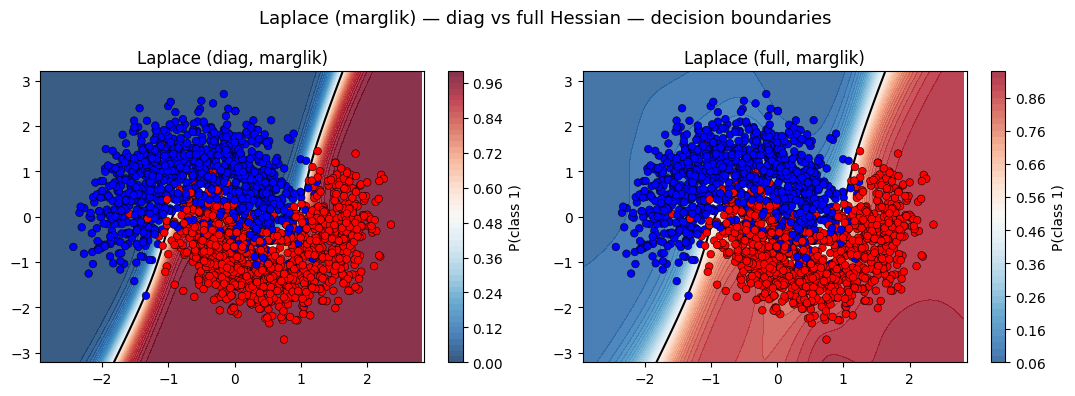

Saved: figures/10_diag_vs_full_boundary.png


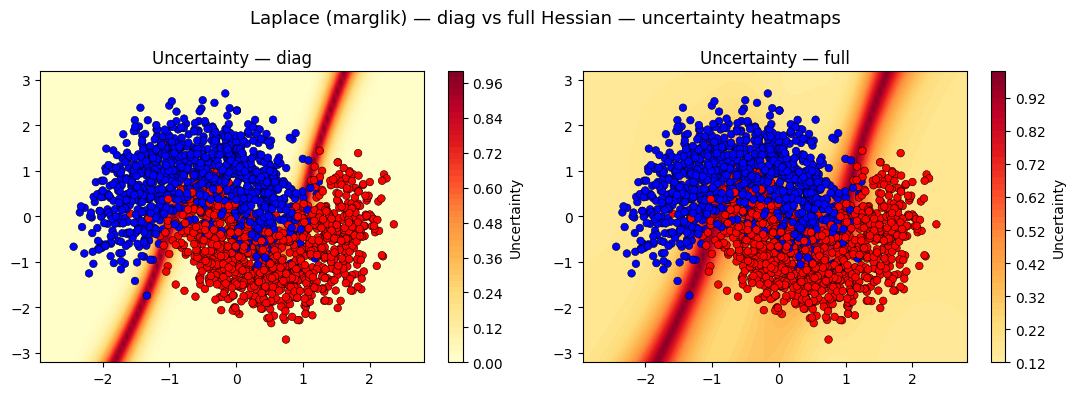

Saved: figures/11_diag_vs_full_uncertainty.png


In [14]:
# ── Figure: Diag vs Full decision boundaries ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cf0, _ = plot_boundary(lambda X: la_predict(X, la_ml),      X_test, y_test, 'Laplace (diag, marglik)', axes[0])
cf1, _ = plot_boundary(lambda X: la_predict(X, la_full), X_test, y_test, 'Laplace (full, marglik)', axes[1])

for cf, ax in zip([cf0, cf1], axes):
    plt.colorbar(cf, ax=ax, label='P(class 1)')

plt.suptitle('Laplace (marglik) — diag vs full Hessian — decision boundaries', fontsize=13)
plt.tight_layout()
plt.savefig('figures/10_diag_vs_full_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/10_diag_vs_full_boundary.png')

# ── Figure: Diag vs Full uncertainty heatmaps ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cf0, _ = uncertainty_map(lambda X: la_predict(X, la_ml),      X_test, y_test, 'Uncertainty — diag', axes[0])
cf1, _ = uncertainty_map(lambda X: la_predict(X, la_full), X_test, y_test, 'Uncertainty — full', axes[1])

for cf, ax in zip([cf0, cf1], axes):
    plt.colorbar(cf, ax=ax, label='Uncertainty')

plt.suptitle('Laplace (marglik) — diag vs full Hessian — uncertainty heatmaps', fontsize=13)
plt.tight_layout()
plt.savefig('figures/11_diag_vs_full_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/11_diag_vs_full_uncertainty.png')

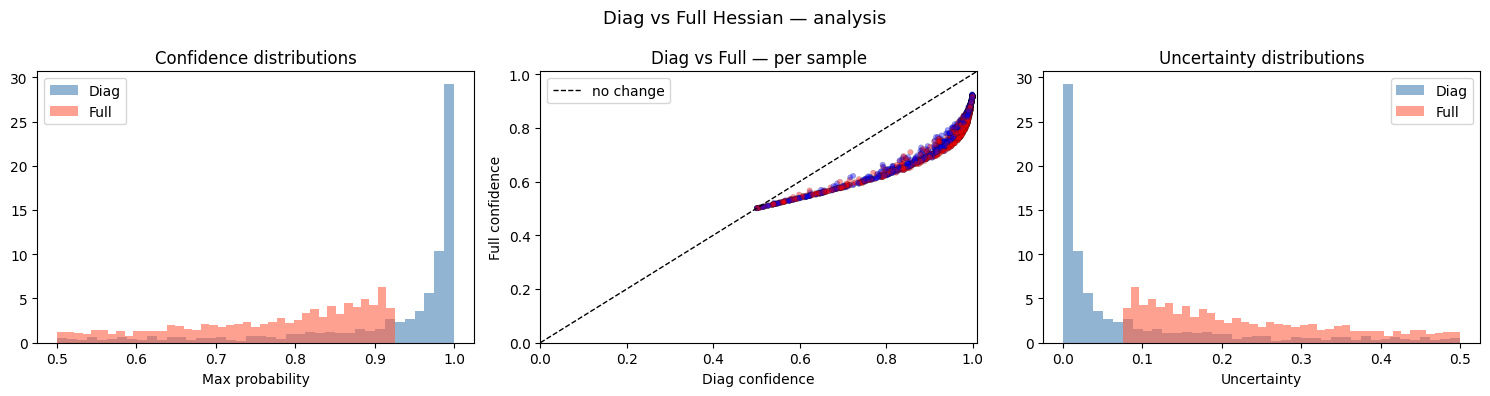

Saved: figures/12_diag_vs_full_analysis.png
Prior precision diag: 8.5844
Prior precision full: 0.5161
Diag accuracy: 92.2%
Full accuracy: 92.2%


In [15]:
# ── Compute per-sample predictions ──
diag_list = []
full_list = []
for i in range(0, len(X_test_t), 64):
    batch = X_test_t[i:i+64]
    with torch.no_grad():
        diag_list.append(la_ml(batch, pred_type='glm', link_approx='probit').cpu())
        full_list.append(la_full(batch, pred_type='glm', link_approx='probit').cpu())

diag_probs = torch.cat(diag_list).numpy()
full_probs = torch.cat(full_list).numpy()

diag_conf = diag_probs.max(axis=1)
full_conf = full_probs.max(axis=1)
diag_unc  = 1 - diag_conf
full_unc  = 1 - full_conf

# ── Figure: Diag vs Full per-sample analysis ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confidence distributions
axes[0].hist(diag_conf, bins=40, alpha=0.6, label='Diag', color=COLOR_DIAG, density=True)
axes[0].hist(full_conf, bins=40, alpha=0.6, label='Full', color=COLOR_FULL, density=True)
axes[0].set_xlabel('Max probability')
axes[0].set_title('Confidence distributions')
axes[0].legend()

# Scatter: Diag (x) vs Full (y)
make_scatter_comparison(axes[1], 'Diag confidence', diag_conf,
                        'Full confidence', full_conf,
                        'Diag vs Full — per sample')

# Uncertainty distributions
axes[2].hist(diag_unc, bins=40, alpha=0.6, label='Diag', color=COLOR_DIAG, density=True)
axes[2].hist(full_unc, bins=40, alpha=0.6, label='Full', color=COLOR_FULL, density=True)
axes[2].set_xlabel('Uncertainty')
axes[2].set_title('Uncertainty distributions')
axes[2].legend()

plt.suptitle('Diag vs Full Hessian — analysis', fontsize=13)
plt.tight_layout()
plt.savefig('figures/12_diag_vs_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/12_diag_vs_full_analysis.png')

print(f'Prior precision diag: {la_ml.prior_precision.item():.4f}')
print(f'Prior precision full: {la_full.prior_precision.item():.4f}')
print(f'Diag accuracy: {(diag_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')
print(f'Full accuracy: {(full_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')

In [16]:
la_kron_marglik = Laplace(
    model,
    'classification',
    subset_of_weights='all',
    hessian_structure='kron'
)

fit_start = time.time()
la_kron_marglik.fit(train_loader)
metrics_dict["Laplace_Kron_MargLik_all"] = {}
metrics_dict["Laplace_Kron_MargLik_all"]["Fit_Time (s)"] = time.time() - fit_start
print('Laplace (kron, marglik) fitted.')

tune_start = time.time()
la_kron_marglik.optimize_prior_precision(method='marglik')
metrics_dict["Laplace_Kron_MargLik_all"]["Tune_Time (s)"] = time.time() - tune_start

print(f'Prior precision (marglik_kron): {la_kron_marglik.prior_precision.item():.4f}')
metrics_dict["Laplace_Kron_MargLik_all"]["Prior_Precision"] = la_kron_marglik.prior_precision.item()

correct = total = 0
inf_start = time.time()
lap_la_kron_marglik_probs = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        probs = la_kron_marglik(xb, pred_type='glm', link_approx='probit')
        preds = probs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += len(yb)
        lap_la_kron_marglik_probs.append(probs)
metrics_dict["Laplace_Kron_MargLik_all"]["Inf_Time (s)"] = time.time() - inf_start
lap_probs_cat = torch.cat(lap_la_kron_marglik_probs).cpu().numpy()
map_unc = float((1 - lap_probs_cat.max(axis=1)).mean())
metrics_dict["Laplace_Kron_MargLik_all"]["Mean_Uncertainty"] = map_unc
print(f'Laplace (kron, marglik) test accuracy: {100*correct/total:.1f}%')

# Store for later use
la_kron = la_kron_marglik  # alias

Laplace (kron, marglik) fitted.
Prior precision (marglik_kron): 1.4092
Laplace (kron, marglik) test accuracy: 92.2%


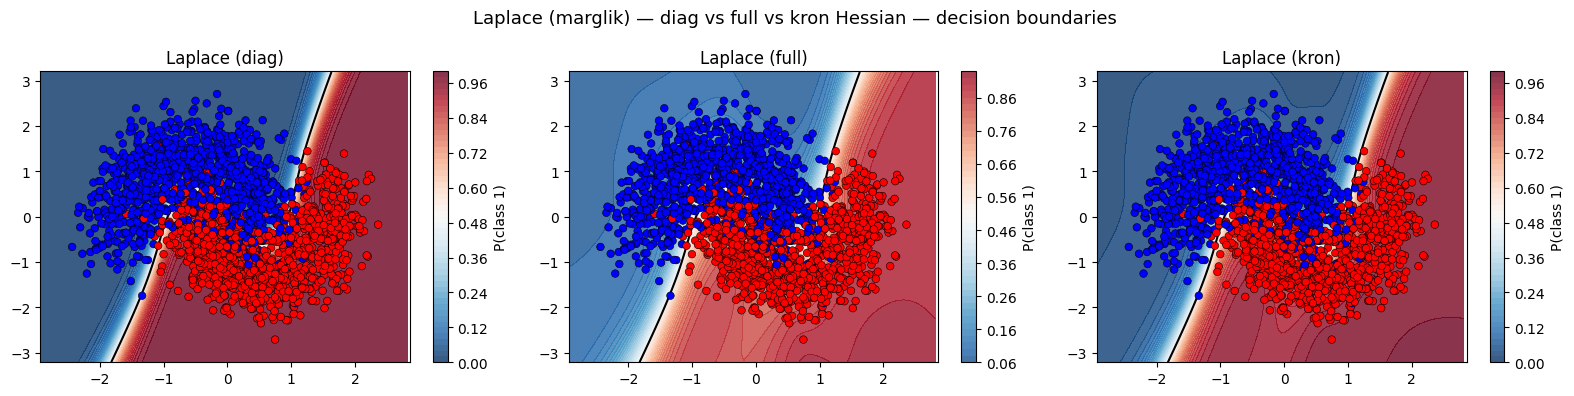

Saved: figures/13_three_hessian_boundary.png


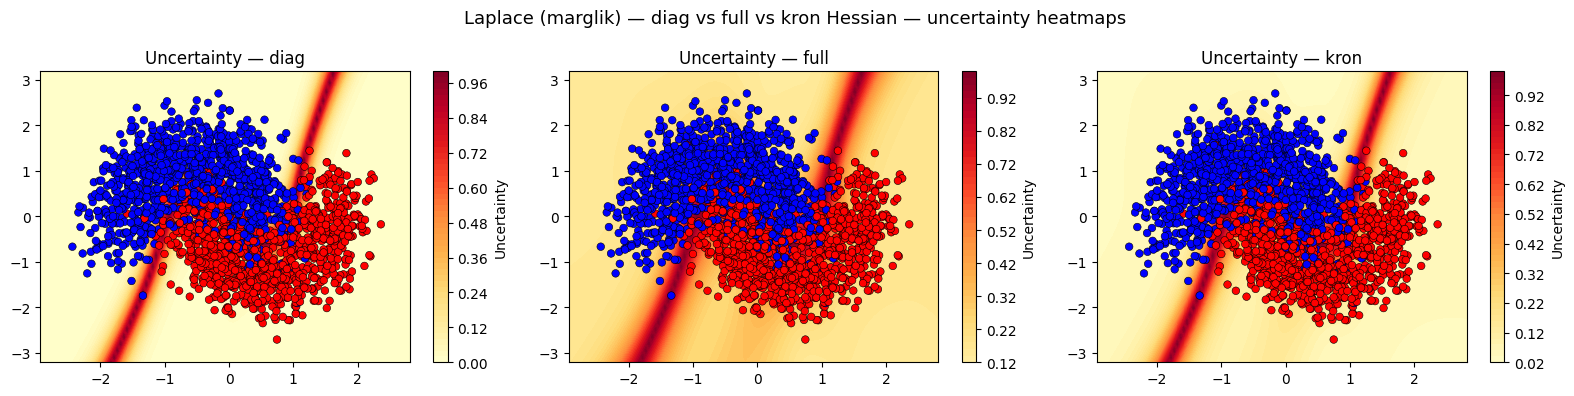

Saved: figures/14_three_hessian_uncertainty.png


In [17]:
# ── Figure: Three Hessian types — decision boundaries ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cf0, _ = plot_boundary(lambda X: la_predict(X, la_ml),      X_test, y_test, 'Laplace (diag)',  axes[0])
cf1, _ = plot_boundary(lambda X: la_predict(X, la_full), X_test, y_test, 'Laplace (full)', axes[1])
cf2, _ = plot_boundary(lambda X: la_predict(X, la_kron), X_test, y_test, 'Laplace (kron)', axes[2])

for cf, ax in zip([cf0, cf1, cf2], axes):
    plt.colorbar(cf, ax=ax, label='P(class 1)')

plt.suptitle('Laplace (marglik) — diag vs full vs kron Hessian — decision boundaries', fontsize=13)
plt.tight_layout()
plt.savefig('figures/13_three_hessian_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/13_three_hessian_boundary.png')

# ── Figure: Three Hessian types — uncertainty heatmaps ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cf0, _ = uncertainty_map(lambda X: la_predict(X, la_ml),      X_test, y_test, 'Uncertainty — diag', axes[0])
cf1, _ = uncertainty_map(lambda X: la_predict(X, la_full), X_test, y_test, 'Uncertainty — full', axes[1])
cf2, _ = uncertainty_map(lambda X: la_predict(X, la_kron), X_test, y_test, 'Uncertainty — kron', axes[2])

for cf, ax in zip([cf0, cf1, cf2], axes):
    plt.colorbar(cf, ax=ax, label='Uncertainty')

plt.suptitle('Laplace (marglik) — diag vs full vs kron Hessian — uncertainty heatmaps', fontsize=13)
plt.tight_layout()
plt.savefig('figures/14_three_hessian_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/14_three_hessian_uncertainty.png')

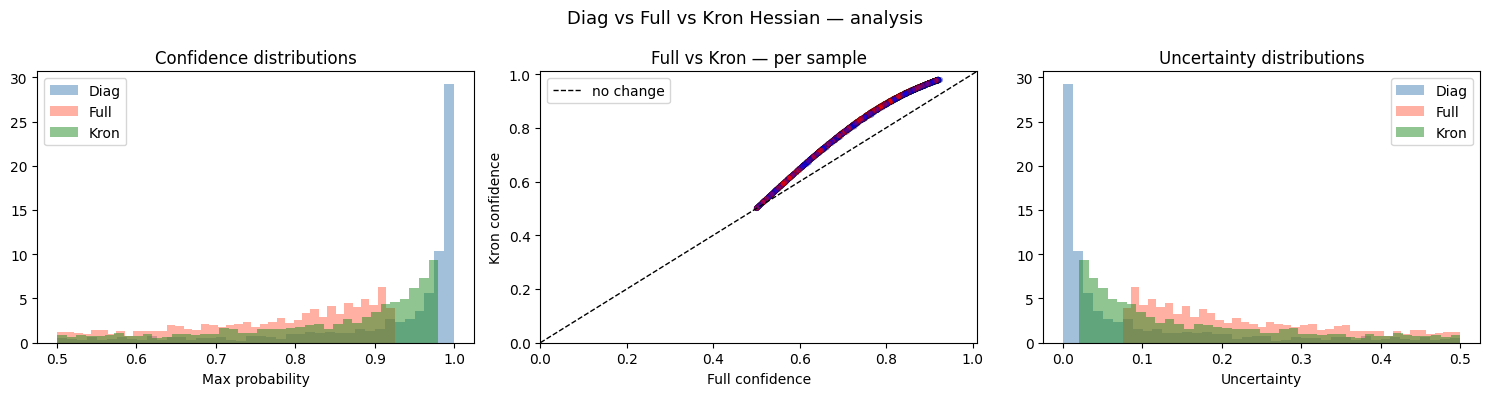

Saved: figures/15_three_hessian_analysis.png
Prior precision diag: 8.5844
Prior precision full: 0.5161
Prior precision kron: 1.4092
Diag accuracy: 92.2%
Full accuracy: 92.2%
Kron accuracy: 92.2%


In [18]:
# ── Compute per-sample predictions ──
kron_list = []
for i in range(0, len(X_test_t), 64):
    batch = X_test_t[i:i+64]
    with torch.no_grad():
        kron_list.append(la_kron(batch, pred_type='glm', link_approx='probit').cpu())
kron_probs = torch.cat(kron_list).numpy()
kron_conf = kron_probs.max(axis=1)
kron_unc  = 1 - kron_conf

# ── Figure: Three Hessian types — per-sample analysis ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confidence distributions
axes[0].hist(diag_conf, bins=40, alpha=0.5, label='Diag', color=COLOR_DIAG, density=True)
axes[0].hist(full_conf, bins=40, alpha=0.5, label='Full', color=COLOR_FULL, density=True)
axes[0].hist(kron_conf, bins=40, alpha=0.5, label='Kron', color=COLOR_KRON, density=True)
axes[0].set_xlabel('Max probability')
axes[0].set_title('Confidence distributions')
axes[0].legend()

# Scatter: Full (x) vs Kron (y)
make_scatter_comparison(axes[1], 'Full confidence', full_conf,
                        'Kron confidence', kron_conf,
                        'Full vs Kron — per sample')

# Uncertainty distributions
axes[2].hist(diag_unc, bins=40, alpha=0.5, label='Diag', color=COLOR_DIAG, density=True)
axes[2].hist(full_unc, bins=40, alpha=0.5, label='Full', color=COLOR_FULL, density=True)
axes[2].hist(kron_unc, bins=40, alpha=0.5, label='Kron', color=COLOR_KRON, density=True)
axes[2].set_xlabel('Uncertainty')
axes[2].set_title('Uncertainty distributions')
axes[2].legend()

plt.suptitle('Diag vs Full vs Kron Hessian — analysis', fontsize=13)
plt.tight_layout()
plt.savefig('figures/15_three_hessian_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/15_three_hessian_analysis.png')

print(f'Prior precision diag: {la_ml.prior_precision.item():.4f}')
print(f'Prior precision full: {la_full.prior_precision.item():.4f}')
print(f'Prior precision kron: {la_kron.prior_precision.item():.4f}')
print(f'Diag accuracy: {(diag_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')
print(f'Full accuracy: {(full_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')
print(f'Kron accuracy: {(kron_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')

=== Two Moons Laplace Setup Benchmarks ===


,Fit_Time (s),Inf_Time (s),Mean_Uncertainty,Tune_Time (s),Prior_Precision
Model Type,,,,,
MAP Baseline,468.1901,0.4818,0.0783,-,-
Laplace_Diag_GridSearch_all,1.3325,0.2909,0.0784,20.2523,10000.0000
Laplace_Diag_MargLik_all,1.2339,0.2791,0.0874,0.1129,8.5844
Laplace_Full_MargLik_all,1092.0908,0.8777,0.2293,6.6640,0.5161
Laplace_Kron_MargLik_all,1.6892,1.2935,0.1590,2.6968,1.4092



Saved metrics to twomoons_bnn_comparison_metrics.csv

=== LaTeX Table Code ===
\begin{tabular}{llllll}
 & Fit_Time (s) & Inf_Time (s) & Mean_Uncertainty & Tune_Time (s) & Prior_Precision \\
Model Type &  &  &  &  &  \\
MAP Baseline & 468.1901 & 0.4818 & 0.0783 & - & - \\
Laplace_Diag_GridSearch_all & 1.3325 & 0.2909 & 0.0784 & 20.2523 & 10000.0000 \\
Laplace_Diag_MargLik_all & 1.2339 & 0.2791 & 0.0874 & 0.1129 & 8.5844 \\
Laplace_Full_MargLik_all & 1092.0908 & 0.8777 & 0.2293 & 6.6640 & 0.5161 \\
Laplace_Kron_MargLik_all & 1.6892 & 1.2935 & 0.1590 & 2.6968 & 1.4092 \\
\end{tabular}



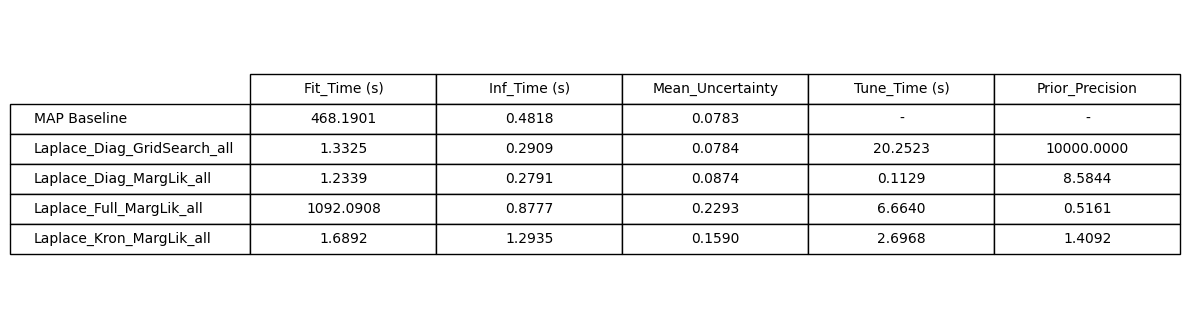

Saved: figures/16_metrics_table.png


In [19]:
# ── Final Export to DataFrame, Table, CSV, and LaTeX ──
df_metrics = pd.DataFrame(metrics_dict).T
df_metrics.index.name = "Model Type"

# Convert numeric columns to formatted strings for display
df_display = df_metrics.copy()
for col in df_display.columns:
    if pd.api.types.is_float_dtype(df_display[col]):
        df_display[col] = df_display[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
    elif pd.api.types.is_integer_dtype(df_display[col]):
        df_display[col] = df_display[col].map(lambda x: str(x) if pd.notna(x) else "-")

print("=== Two Moons Laplace Setup Benchmarks ===")
display(df_display)

# Save to CSV
csv_path = "twomoons_bnn_comparison_metrics.csv"
df_metrics.to_csv(csv_path)
print(f"\nSaved metrics to {csv_path}")

# Output as LaTeX for academic report
print("\n=== LaTeX Table Code ===")
latex_str = df_display.style.format(precision=4).to_latex()
print(latex_str)

# ── Figure: Metrics table ──
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
the_table = ax.table(cellText=df_display.values, colLabels=df_display.columns,
                     rowLabels=df_display.index, cellLoc='center', loc='center')
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.8)
plt.savefig('figures/16_metrics_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/16_metrics_table.png')

## LaTeX Figure References

All figures are saved in the `figures/` directory with consistent numbering. Here is a mapping for your LaTeX report:

| Figure | Filename | Description |
|--------|----------|-------------|
| 1 | `01_raw_dataset.png` | Raw Two Moons dataset |
| 2 | `02_map_training_loss.png` | MAP training loss curve |
| 3 | `03_map_boundary.png` | MAP decision boundary |
| 4 | `04_laplace_diag_grid_boundary.png` | Laplace (diag, gridsearch) boundary |
| 5 | `05_map_vs_laplace_boundary.png` | MAP vs Laplace boundaries |
| 6 | `06_map_vs_laplace_uncertainty.png` | MAP vs Laplace uncertainty |
| 7 | `07_three_way_boundary.png` | MAP vs Laplace grid vs marglik boundaries |
| 8 | `08_three_way_uncertainty.png` | Three-way uncertainty heatmaps |
| 9 | `09_three_way_analysis.png` | Three-way per-sample analysis |
| 10 | `10_diag_vs_full_boundary.png` | Diag vs Full boundaries |
| 11 | `11_diag_vs_full_uncertainty.png` | Diag vs Full uncertainty |
| 12 | `12_diag_vs_full_analysis.png` | Diag vs Full per-sample |
| 13 | `13_three_hessian_boundary.png` | Diag vs Full vs Kron boundaries |
| 14 | `14_three_hessian_uncertainty.png` | Three Hessian uncertainty |
| 15 | `15_three_hessian_analysis.png` | Three Hessian per-sample |
| 16 | `16_metrics_table.png` | Metrics table |

### LaTeX inclusion example:
```latex
\begin{figure}[htbp]
    \centering
    \includegraphics[width=0.9\textwidth]{figures/05_map_vs_laplace_boundary}
    \caption{MAP vs Laplace (diag, gridsearch) decision boundaries.}
    \label{fig:map_vs_laplace}
\end{figure}
```

### Color legend for figures:
- **Steel Blue** (`#4682B4`): MAP / Diag
- **Tomato** (`#FF6347`): Full
- **Forest Green** (`#228B22`): Kron / Marglik
- **Medium Purple** (`#9370DB`): Gridsearch